#Problem Statement
The objective of this project is to develop a machine learning model to predict whether a patient has diabetes based on diagnostic features such as glucose level, BMI, age, and other medical attributes from the Pima Indians Diabetes dataset.

In [25]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#1. Load Dataset

In [3]:
# Load the fitness dataset
df = pd.read_csv('/diabetes.csv')

In [4]:
print('Shape:', df.shape)

Shape: (768, 9)


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
tf = df.copy()

In [10]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']
df[cols] = df[cols].replace(0, np.nan)

In [11]:
# Basic info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [12]:
# Statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#2. Null Value Treatment

In [13]:
# Check null counts before treatment
print('Null values before treatment:')
print(df.isnull().sum())

Null values before treatment:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [14]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']

In [16]:
for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].median())

In [18]:
print('Null values after treatment:')
print(df.isnull().sum())

Null values after treatment:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#3. Outlier detection and removal by capping using IQR Method

In [19]:

cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Apply IQR-based capping
for col in cols_with_zero:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

#4. Visualisations

array([[<Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>],
       [<Axes: title={'center': 'BMI'}>, <Axes: >]], dtype=object)

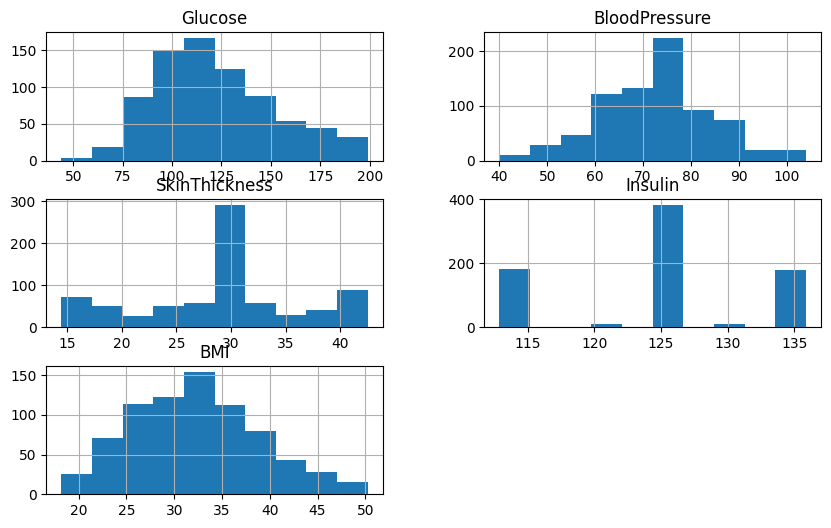

In [20]:
df[cols_with_zero].hist(figsize=(10,6))

#5. Model Training - Logistic Regression and KNN

In [22]:
# Define features (X) and target (y)
X = df.drop(columns=['Outcome'], axis=1)
y = df['Outcome']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (614, 8)
Test size : (154, 8)


In [23]:
# Apply StandardScaler to normalize feature values.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Train Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

#6. Model Evaluation

In [29]:
# Predictions
lr_pred = lr.predict(X_test)
knn_pred = knn.predict(X_test)

In [30]:
#Accuracy
acc_lr = accuracy_score(y_test, lr_pred)
acc_knn = accuracy_score(y_test, knn_pred)
print("Logistic Regression Accuracy:", acc_lr)
print("KNN Accuracy:", acc_knn)

Logistic Regression Accuracy: 0.7012987012987013
KNN Accuracy: 0.7337662337662337


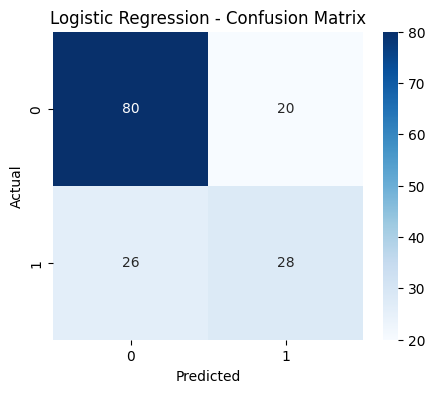

In [32]:
# Logistic Regression CM
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

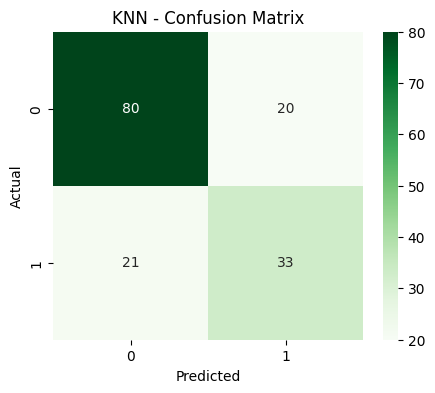

In [33]:
# KNN CM
cm_knn = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [34]:
#Classification reports
cr_lr = classification_report(y_test, lr_pred)
cr_knn = classification_report(y_test, knn_pred)
print("\nLogistic Regression Report:\n", cr_lr)
print("\nKNN Report:\n", cr_knn)


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


KNN Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

